In [3]:
import pandas as pd
import os
import glob
from tqdm import tqdm
import cudf as cd
import time
import matplotlib.pyplot as plt
import gc

In [4]:
def transfer_times(data):
    times = []
    iterations = 1
    # print_gpu_memory_usage_pynvml(device_id=0)
    # for i in range(iterations):
    # cuda.synchronize()
    cudf_df = cd.DataFrame()
    start_time = time.perf_counter()

    # cudf_df = cd.DataFrame.from_pandas(data)
    # cudf_df = cd.DataFrame()
    cudf_df["col"] = data
    # print(type(cudf_df))
    # cudf_df = cd.Series.from_pandas(data)

    # cuda.synchronize()
    end_time = time.perf_counter()
    times.append(end_time - start_time)

    # print(type(cudf_df))
    # del cudf_df
    # print_gpu_memory_usage_pynvml(device_id=0)
    # import pdb;pdb.set_trace()
    # elapsed_time = sum(times)/ iterations
    elapsed_time = times[0]
    return elapsed_time * 1000

In [5]:
def ideal_transfer_time(data):
    memory_usage = data.memory_usage(deep=True).sum()
    memory_usage = memory_usage / 10**9
    ideal_time = memory_usage / 16  # bandwidith is 16GB/s
    # print(memory_usage)
    return ideal_time * 1000, memory_usage

In [6]:
input_dir = "/home/jupyter/generated_dataframes_columns_string"  #'/home/jupyter/generated_dataframes_integer_columns'
file_pattern = os.path.join(input_dir, "*.parquet")
files = glob.glob(file_pattern)

results_list = []

for file in tqdm(files):
    if ".parquet" in file:
        data = pd.read_parquet(file)
        col = data.columns[0]
        elapsed_time = transfer_times(data[col])
        ideal_time, memory_usage = ideal_transfer_time(data)
        results_list.append(
            {
                "memory_usage": memory_usage,
                "elapsed_time": elapsed_time,
                "ideal_time": ideal_time,
                "n_cols": len(data.columns),
                "n_rows": len(data),
            }
        )
        # if random.random() < 0.2:  # 50% chance
        #     gc.collect()
        #     del data
        del data
        gc.collect()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15000/15000 [1:12:25<00:00,  3.45it/s]


In [7]:
results_df = pd.DataFrame(results_list)

In [ ]:
results_df[results_df["memory_usage"]]

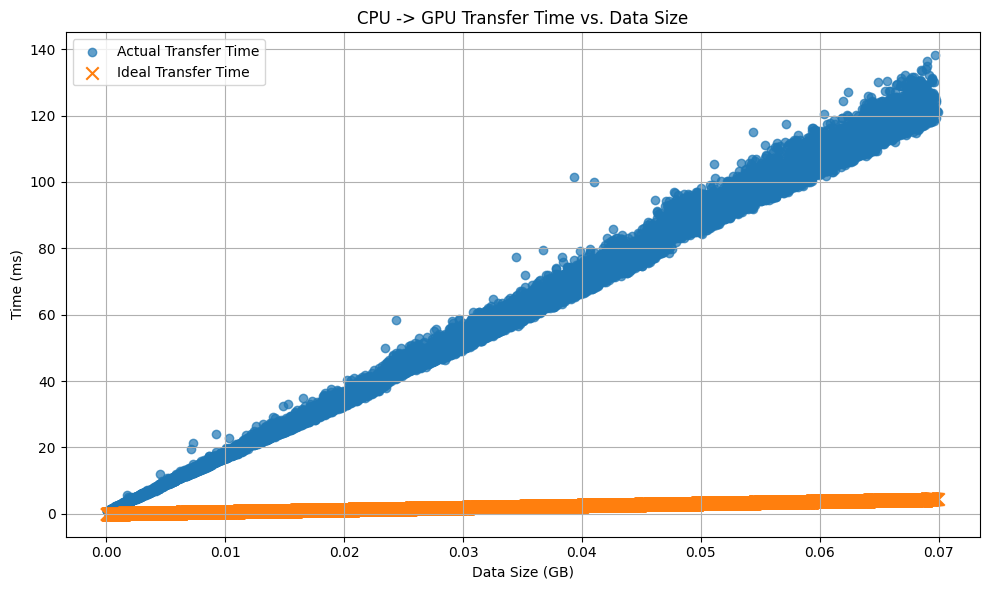

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(
    results_df["memory_usage"],
    results_df["elapsed_time"],
    label="Actual Transfer Time",
    alpha=0.7,
)
plt.scatter(
    results_df["memory_usage"],
    results_df["ideal_time"],
    label="Ideal Transfer Time",
    marker="x",
    s=80,
)
# plt.scatter(results_df_iter['memory_usage'], results_df_iter['elapsed_time'], label='Actual Transfer Time iter', alpha=0.7)
# plt.scatter(results_df_iter['memory_usage'], results_df_iter['ideal_time'], label='Ideal Transfer Time iter', marker='x', s=80)
# Optional: Plot lines if data sizes are somewhat ordered
# plt.plot(results_df.sort_values('memory_usage')['memory_usage'], results_df.sort_values('memory_usage')['elapsed_time'], marker='o', linestyle='-', label='Actual Transfer Time')
# plt.plot(results_df.sort_values('memory_usage')['memory_usage'], results_df.sort_values('memory_usage')['ideal_time'], marker='x', linestyle='--', label='Ideal Transfer Time')
plt.xlabel("Data Size (GB)")
plt.ylabel("Time (ms)")
plt.title("CPU -> GPU Transfer Time vs. Data Size")
plt.legend()
# plt.ylim(0, 40)
plt.grid(True)
plt.tight_layout()
plt.show()

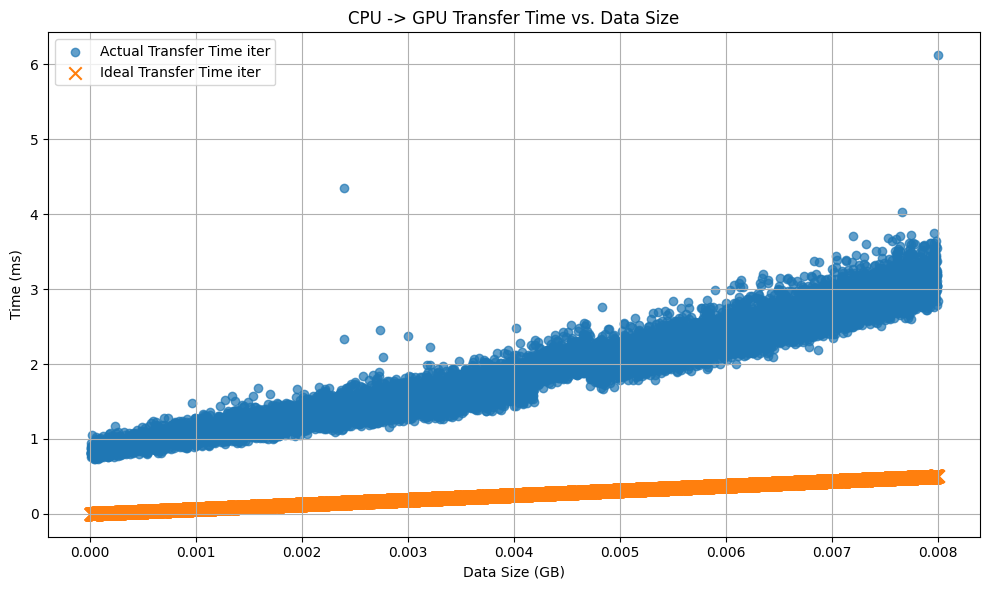

In [12]:
plt.figure(figsize=(10, 6))
# plt.scatter(results_df['memory_usage'], results_df['elapsed_time'], label='Actual Transfer Time', alpha=0.7)
# plt.scatter(results_df['memory_usage'], results_df['ideal_time'], label='Ideal Transfer Time', marker='x', s=80)
plt.scatter(
    results_df_iter["memory_usage"],
    results_df_iter["elapsed_time"],
    label="Actual Transfer Time iter",
    alpha=0.7,
)
plt.scatter(
    results_df_iter["memory_usage"],
    results_df_iter["ideal_time"],
    label="Ideal Transfer Time iter",
    marker="x",
    s=80,
)
# Optional: Plot lines if data sizes are somewhat ordered
# plt.plot(results_df.sort_values('memory_usage')['memory_usage'], results_df.sort_values('memory_usage')['elapsed_time'], marker='o', linestyle='-', label='Actual Transfer Time')
# plt.plot(results_df.sort_values('memory_usage')['memory_usage'], results_df.sort_values('memory_usage')['ideal_time'], marker='x', linestyle='--', label='Ideal Transfer Time')
plt.xlabel("Data Size (GB)")
plt.ylabel("Time (ms)")
plt.title("CPU -> GPU Transfer Time vs. Data Size")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

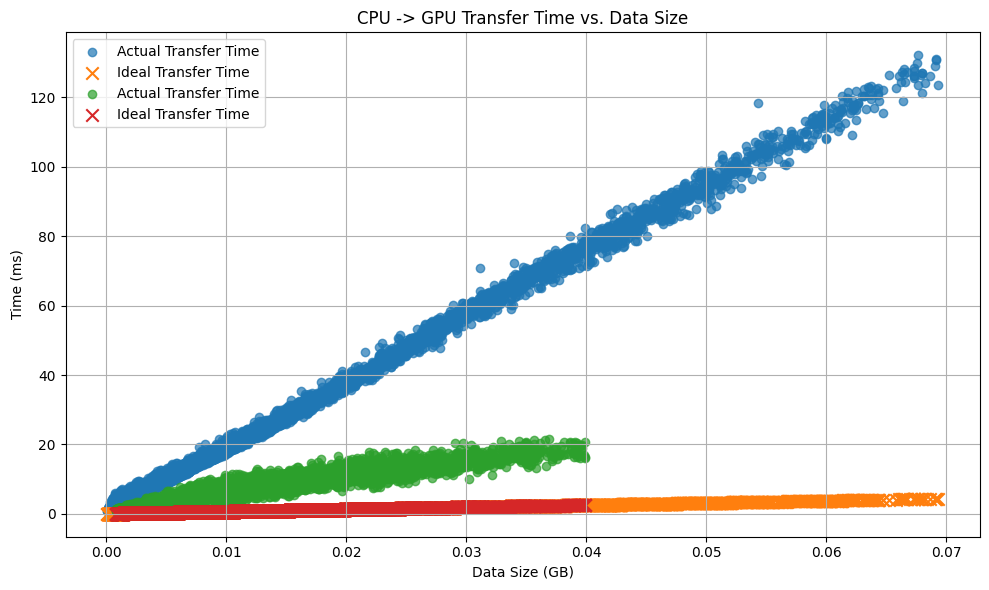

In [21]:
plt.figure(figsize=(10, 6))
plt.scatter(
    results_df["memory_usage"],
    results_df["elapsed_time"],
    label="Actual Transfer Time",
    alpha=0.7,
)
plt.scatter(
    results_df["memory_usage"],
    results_df["ideal_time"],
    label="Ideal Transfer Time",
    marker="x",
    s=80,
)
plt.scatter(
    results_df_num["memory_usage"],
    results_df_num["elapsed_time"],
    label="Actual Transfer Time",
    alpha=0.7,
)
plt.scatter(
    results_df_num["memory_usage"],
    results_df_num["ideal_time"],
    label="Ideal Transfer Time",
    marker="x",
    s=80,
)
# Optional: Plot lines if data sizes are somewhat ordered
# plt.plot(results_df.sort_values('memory_usage')['memory_usage'], results_df.sort_values('memory_usage')['elapsed_time'], marker='o', linestyle='-', label='Actual Transfer Time')
# plt.plot(results_df.sort_values('memory_usage')['memory_usage'], results_df.sort_values('memory_usage')['ideal_time'], marker='x', linestyle='--', label='Ideal Transfer Time')
plt.xlabel("Data Size (GB)")
plt.ylabel("Time (ms)")
plt.title("CPU -> GPU Transfer Time vs. Data Size")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

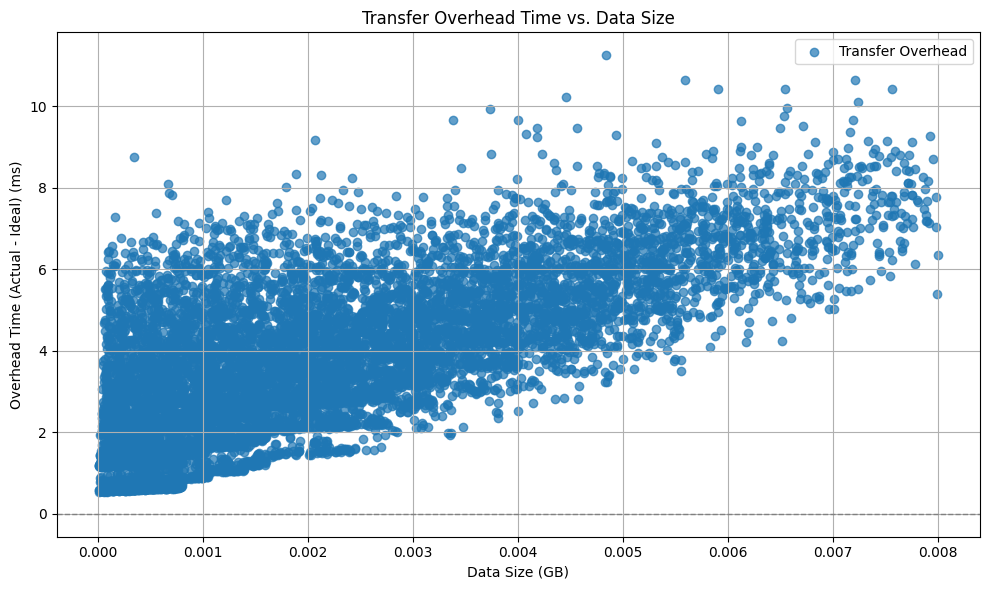

In [14]:
results_df["overhead_ms"] = results_df["elapsed_time"] - results_df["ideal_time"]
plt.figure(figsize=(10, 6))
plt.scatter(
    results_df["memory_usage"],
    results_df["overhead_ms"],
    label="Transfer Overhead",
    alpha=0.7,
)
# Optional: Add a trend line if desired
# z = np.polyfit(results_df['memory_usage'], results_df['overhead_ms'], 1)
# p = np.poly1d(z)
# plt.plot(results_df['memory_usage'], p(results_df['memory_usage']), "r--", label=f'Trendline (y={z[0]:.2f}x+{z[1]:.2f})')
plt.xlabel("Data Size (GB)")
plt.ylabel("Overhead Time (Actual - Ideal) (ms)")
plt.title("Transfer Overhead Time vs. Data Size")
plt.axhline(0, color="grey", linestyle="--", lw=1)  # Zero overhead line
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Training set size: 12000
Testing set size: 3000

Training XGBoost model...
Training complete.

--- XGBoost Model Evaluation (on Test Set) ---
  Mean Squared Error (MSE): 5.9646
  R-squared (R²): 0.9954


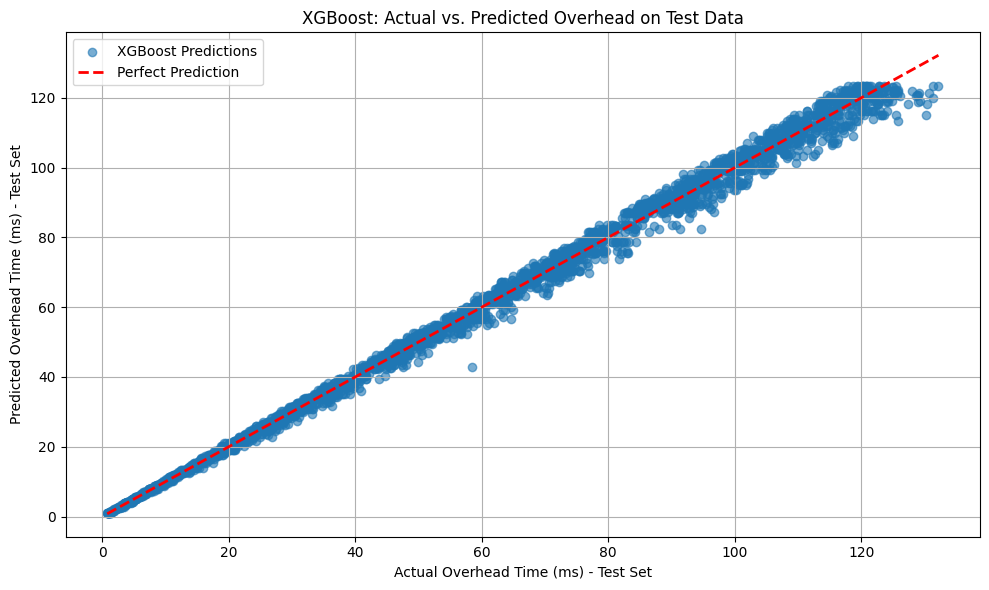

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# --- Assume results_df is already populated ---
# results_df = pd.DataFrame(results_list)
# results_df['overhead_ms'] = results_df['elapsed_time'] - results_df['ideal_time']
# ----------------------------------------------

if results_df.empty:
    print(
        "Results DataFrame is empty or missing 'overhead_ms' column. Cannot train model."
    )
else:
    # 1. Prepare Data
    results_df_clean = results_df.dropna(subset=["memory_usage"])
    if results_df_clean.empty:
        print("No valid data points remain after removing NaNs.")
    else:
        X = results_df_clean[["memory_usage"]].values  # Feature (needs to be 2D)
        y = results_df_clean["elapsed_time"].values  # Target

        # --- IMPORTANT: Split data into Training and Testing sets ---
        # Use 80% for training, 20% for testing. random_state ensures reproducibility.
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        print(f"Training set size: {X_train.shape[0]}")
        print(f"Testing set size: {X_test.shape[0]}")

        # 2. Create and Configure the XGBoost Regressor Model
        # Common parameters:
        # n_estimators: Number of boosting rounds (trees)
        # learning_rate: Step size shrinkage to prevent overfitting
        # max_depth: Maximum depth of each tree
        # objective: Loss function ('reg:squarederror' for regression)
        # early_stopping_rounds: Stop training if validation score doesn't improve
        # random_state: For reproducibility
        xgb_model = xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=100,  # Start with 100 trees, can tune this
            learning_rate=0.1,  # Common starting point
            max_depth=10,  # Shallow trees often work well initially
            subsample=0.8,  # Use 80% of data per tree (helps prevent overfitting)
            colsample_bytree=1.0,  # Use all features (only one here anyway)
            random_state=42,
            n_jobs=-1,  # Use all available CPU cores
        )

        # 3. Train the Model (with early stopping)
        # We use the test set as the evaluation set here for simplicity,
        # though a separate validation set is often preferred in rigorous workflows.
        print("\nTraining XGBoost model...")
        xgb_model.fit(
            X_train,
            y_train,
            eval_set=[(X_test, y_test)],  # Monitor performance on the test set
            verbose=False,  # Set to True to see training progress per round
        )
        print("Training complete.")

        # 4. Make Predictions on the Test Set
        y_pred_xgb = xgb_model.predict(X_test)

        # 5. Evaluate the Model on the Test Set
        mse_xgb = mean_squared_error(y_test, y_pred_xgb)
        r2_xgb = r2_score(y_test, y_pred_xgb)

        print("\n--- XGBoost Model Evaluation (on Test Set) ---")
        print(f"  Mean Squared Error (MSE): {mse_xgb:.4f}")
        print(f"  R-squared (R²): {r2_xgb:.4f}")

        # Compare with Linear Model (if evaluated on the same test set - otherwise compare cautiously)
        # You might want to re-run the linear model evaluation on the *same* train/test split
        # from sklearn.linear_model import LinearRegression
        # linear_model_eval = LinearRegression()
        # linear_model_eval.fit(X_train, y_train)
        # y_pred_linear_test = linear_model_eval.predict(X_test)
        # mse_linear_test = mean_squared_error(y_test, y_pred_linear_test)
        # r2_linear_test = r2_score(y_test, y_pred_linear_test)
        # print(f"\n--- Linear Model Evaluation (on Test Set for Comparison) ---")
        # print(f"  Mean Squared Error (MSE): {mse_linear_test:.4f}")
        # print(f"  R-squared (R²): {r2_linear_test:.4f}")

        # 6. Visualize Predictions vs. Actuals (on Test Set)
        plt.figure(figsize=(10, 6))
        plt.scatter(y_test, y_pred_xgb, alpha=0.6, label="XGBoost Predictions")
        # Add the perfect prediction line (y=x)
        min_val = min(min(y_test), min(y_pred_xgb))
        max_val = max(max(y_test), max(y_pred_xgb))
        plt.plot(
            [min_val, max_val],
            [min_val, max_val],
            color="red",
            linestyle="--",
            linewidth=2,
            label="Perfect Prediction",
        )
        plt.xlabel("Actual Overhead Time (ms) - Test Set")
        plt.ylabel("Predicted Overhead Time (ms) - Test Set")
        plt.title("XGBoost: Actual vs. Predicted Overhead on Test Data")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Optional: Plot Feature Importance (less interesting with only one feature)
        # xgb.plot_importance(xgb_model)
        # plt.title("Feature Importance (XGBoost)")
        # plt.show()

        # # --- How to use the trained XGBoost model to estimate cost ---
        # new_data_size_gb = 0.005 # Example: 5 MB
        # # Model expects a 2D array
        # new_data_point = np.array([[new_data_size_gb]])
        # estimated_overhead_ms_xgb = xgb_model.predict(new_data_point)[0]
        # print(f"\nEstimated overhead for {new_data_size_gb:.4f} GB using XGBoost: {estimated_overhead_ms_xgb:.4f} ms")

        # Combine with ideal time... (same logic as before)
        # ASSUMED_IDEAL_BW_GBps = 12.0
        # ideal_time_s = new_data_size_gb / ASSUMED_IDEAL_BW_GBps
        # ideal_time_ms_new = ideal_time_s * 1000
        # estimated_total_time_ms_xgb = ideal_time_ms_new + estimated_overhead_ms_xgb
        # print(f"Estimated total transfer time via XGBoost: {estimated_total_time_ms_xgb:.4f} ms")

In [22]:
0.6609**1 / 2

0.33045

## Linear Regression

Using 15000 data points for modeling.

Training set features shape: (12000, 1)
Testing set features shape: (3000, 1)

Training Linear Regression model (features: ideal_time, memory_gb)...
Training complete.

--- Linear Regression Model Parameters ---
Equation: Actual_Time ≈ ( (1789.7797 * Memory_GB) + -0.5928
Coefficient for memory_gb: 1789.7797
Intercept:                 -0.5928 ms

--- Model Evaluation (on Test Set) ---
  Mean Squared Error (MSE):      6.4350 (ms^2)
  Root Mean Squared Error (RMSE):2.5367 (ms)
  Mean Absolute Error (MAE):     1.8626 (ms)
  R-squared (R²):                0.9951


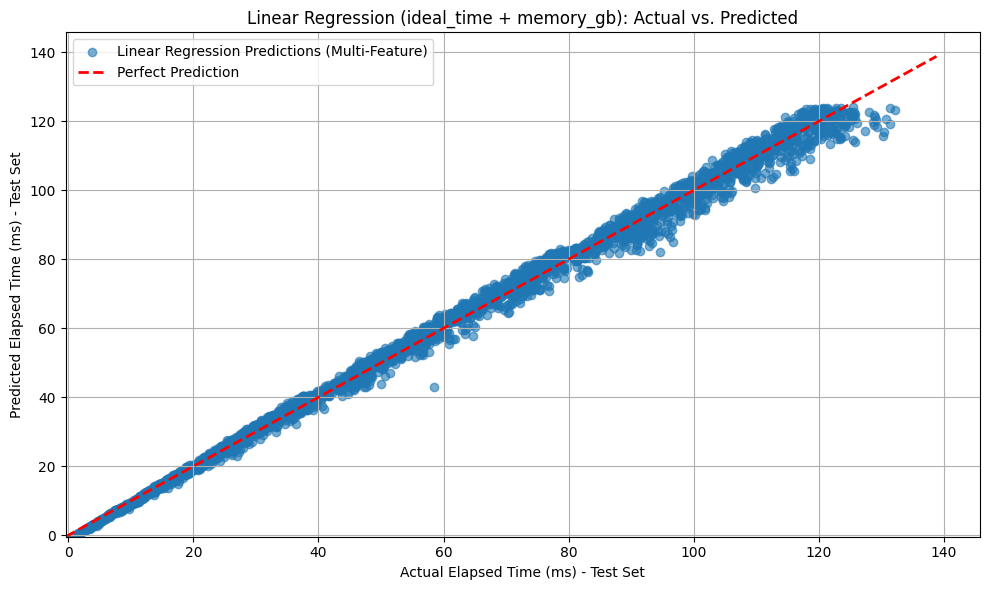


Estimated actual time for ideal=2.5ms, memory=0.070036GB: 124.7562 ms


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# --- Assume results_df is already populated ---
# It MUST contain 'elapsed_time', 'ideal_time', and 'memory_gb'
# Example creation if needed:
# results_list = [{'elapsed_time': 5.2, 'ideal_time': 1.1, 'memory_gb': 0.001, ...}, {...}]
# results_df = pd.DataFrame(results_list)
# -----------------------------------------------------------------------

# Check if DataFrame and necessary columns exist
if "results_df" not in locals() or results_df.empty:
    print("Error: 'results_df' not found or is empty. Please load your results.")
elif not all(
    col in results_df.columns for col in ["elapsed_time", "ideal_time", "memory_usage"]
):
    print(
        "Error: 'results_df' must contain 'elapsed_time', 'ideal_time', and 'memory_gb' columns."
    )
else:
    # 1. Prepare Data
    # Define features (X) and target (y)
    feature_columns = ["memory_usage"]  # <<< Added memory_gb
    target_column = "elapsed_time"
    all_columns = feature_columns + [target_column]

    # Drop rows where any required column has NaN
    results_df_clean = results_df.dropna(subset=all_columns)

    if results_df_clean.empty:
        print("No valid data points remain after removing NaNs.")
    else:
        print(f"Using {len(results_df_clean)} data points for modeling.")

        # Extract features (X) - Should be 2D: (n_samples, n_features)
        X = results_df[feature_columns].values
        # Extract target (y) - Should be 1D: (n_samples,)
        y = results_df[target_column].values

        # 2. Split Data into Training and Testing sets
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        print(f"\nTraining set features shape: {X_train.shape}")
        print(f"Testing set features shape: {X_test.shape}")

        # 3. Create and Train the Linear Regression Model
        print("\nTraining Linear Regression model (features: ideal_time, memory_gb)...")
        lin_reg_model_multi = LinearRegression(positive=True)
        lin_reg_model_multi.fit(X_train, y_train)
        print("Training complete.")

        # 4. Get Model Parameters (Coefficients)
        # The order matches the feature_columns list
        # coef_ideal_time = lin_reg_model_multi.coef_[0]
        coef_memory_gb = lin_reg_model_multi.coef_[0]

        intercept = lin_reg_model_multi.intercept_

        print("\n--- Linear Regression Model Parameters ---")
        print(
            f"Equation: Actual_Time ≈ ( ({coef_memory_gb:.4f} * Memory_GB) + {intercept:.4f}"
        )
        # print(f"Coefficient for ideal_time:  {coef_ideal_time:.4f}")
        print(f"Coefficient for memory_gb: {coef_memory_gb:.4f}")
        print(f"Intercept:                 {intercept:.4f} ms")

        # 5. Make Predictions on the Test Set
        y_pred = lin_reg_model_multi.predict(X_test)

        # 6. Evaluate the Model on the Test Set
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print("\n--- Model Evaluation (on Test Set) ---")
        print(f"  Mean Squared Error (MSE):      {mse:.4f} (ms^2)")
        print(f"  Root Mean Squared Error (RMSE):{rmse:.4f} (ms)")
        print(f"  Mean Absolute Error (MAE):     {mae:.4f} (ms)")
        print(f"  R-squared (R²):                {r2:.4f}")
        # Compare this R² to the model using only ideal_time. Did it improve much?

        # 7. Visualize Predictions vs. Actuals (on Test Set) - Still useful
        plt.figure(figsize=(10, 6))
        plt.scatter(
            y_test,
            y_pred,
            alpha=0.6,
            label="Linear Regression Predictions (Multi-Feature)",
        )
        min_val = min(min(y_test), min(y_pred)) * 0.95
        max_val = max(max(y_test), max(y_pred)) * 1.05
        plt.plot(
            [min_val, max_val],
            [min_val, max_val],
            color="red",
            linestyle="--",
            linewidth=2,
            label="Perfect Prediction",
        )
        plt.xlabel("Actual Elapsed Time (ms) - Test Set")
        plt.ylabel("Predicted Elapsed Time (ms) - Test Set")
        plt.title("Linear Regression (ideal_time + memory_gb): Actual vs. Predicted")
        plt.legend()
        plt.grid(True)
        plt.xlim(left=min_val)
        plt.ylim(bottom=min_val)
        plt.tight_layout()
        plt.show()

        # Optional: Residual Plot
        # ... (code for residual plot as before) ...

        # --- How to use the trained model for new predictions ---
        # Example: Predict actual time for ideal=2.5ms and memory=0.0002GB
        new_ideal_time_ms = 2.5
        new_memory_gb = (
            70036000 / 10**9
        )  # Approx 0.2MB, need to be consistent with ideal_time calculation
        # Create a 2D array with features in the SAME order as training
        new_data_point = np.array([[new_memory_gb]])

        predicted_actual_time = lin_reg_model_multi.predict(new_data_point)[0]
        print(
            f"\nEstimated actual time for ideal={new_ideal_time_ms}ms, memory={new_memory_gb}GB: {predicted_actual_time:.4f} ms"
        )

positive intercept

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# --- Assume results_df is already populated ---
# It MUST contain 'elapsed_time', 'ideal_time', and 'memory_gb'
# Example creation if needed:
# results_list = [{'elapsed_time': 5.2, 'ideal_time': 1.1, 'memory_gb': 0.001, ...}, {...}]
# results_df = pd.DataFrame(results_list)
# -----------------------------------------------------------------------

# Check if DataFrame and necessary columns exist
if "results_df" not in locals() or results_df.empty:
    print("Error: 'results_df' not found or is empty. Please load your results.")
elif not all(
    col in results_df.columns for col in ["elapsed_time", "ideal_time", "memory_usage"]
):
    print(
        "Error: 'results_df' must contain 'elapsed_time', 'ideal_time', and 'memory_gb' columns."
    )
else:
    # 1. Prepare Data
    # Define features (X) and target (y)
    feature_columns = ["memory_usage"]  # <<< Added memory_gb
    target_column = "elapsed_time"
    all_columns = feature_columns + [target_column]

    # Drop rows where any required column has NaN
    results_df_clean = results_df.dropna(subset=all_columns)

    if results_df_clean.empty:
        print("No valid data points remain after removing NaNs.")
    else:
        print(f"Using {len(results_df_clean)} data points for modeling.")

        # Extract features (X) - Should be 2D: (n_samples, n_features)
        X = results_df[feature_columns].values
        # Extract target (y) - Should be 1D: (n_samples,)
        y = results_df[target_column].values

        # 2. Split Data into Training and Testing sets
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        ones = np.ones((X_train.shape[0], 1))
        X_aug = np.hstack([ones, X_train])
        print(f"\nTraining set features shape: {X_train.shape}")
        print(f"Testing set features shape: {X_test.shape}")

        # 3. Create and Train the Linear Regression Model
        print("\nTraining Linear Regression model (features: ideal_time, memory_gb)...")
        lin_reg_model_multi = LinearRegression(fit_intercept=False, positive=True)
        lin_reg_model_multi.fit(X_aug, y_train)
        print("Training complete.")

        # 4. Get Model Parameters (Coefficients)
        # The order matches the feature_columns list
        # coef_ideal_time = lin_reg_model_multi.coef_[0]
        print(lin_reg_model_multi.coef_)
        coef_memory_gb = lin_reg_model_multi.coef_[1:][0]
        intercept = lin_reg_model_multi.coef_[0]
        # intercept = lin_reg_model_multi.intercept_

        print("\n--- Linear Regression Model Parameters ---")
        print(
            f"Equation: Actual_Time ≈ ( ({coef_memory_gb:.4f} * Memory_GB) + {intercept:.4f}"
        )
        # print(f"Coefficient for ideal_time:  {coef_ideal_time:.4f}")
        print(f"Coefficient for memory_gb: {coef_memory_gb:.4f}")
        print(f"Intercept:                 {intercept:.4f} ms")

        # 5. Make Predictions on the Test Set
        y_pred = lin_reg_model_multi.predict(X_test)

        # 6. Evaluate the Model on the Test Set
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print("\n--- Model Evaluation (on Test Set) ---")
        print(f"  Mean Squared Error (MSE):      {mse:.4f} (ms^2)")
        print(f"  Root Mean Squared Error (RMSE):{rmse:.4f} (ms)")
        print(f"  Mean Absolute Error (MAE):     {mae:.4f} (ms)")
        print(f"  R-squared (R²):                {r2:.4f}")
        # Compare this R² to the model using only ideal_time. Did it improve much?

        # 7. Visualize Predictions vs. Actuals (on Test Set) - Still useful
        plt.figure(figsize=(10, 6))
        plt.scatter(
            y_test,
            y_pred,
            alpha=0.6,
            label="Linear Regression Predictions (Multi-Feature)",
        )
        min_val = min(min(y_test), min(y_pred)) * 0.95
        max_val = max(max(y_test), max(y_pred)) * 1.05
        plt.plot(
            [min_val, max_val],
            [min_val, max_val],
            color="red",
            linestyle="--",
            linewidth=2,
            label="Perfect Prediction",
        )
        plt.xlabel("Actual Elapsed Time (ms) - Test Set")
        plt.ylabel("Predicted Elapsed Time (ms) - Test Set")
        plt.title("Linear Regression (ideal_time + memory_gb): Actual vs. Predicted")
        plt.legend()
        plt.grid(True)
        plt.xlim(left=min_val)
        plt.ylim(bottom=min_val)
        plt.tight_layout()
        plt.show()

        # Optional: Residual Plot
        # ... (code for residual plot as before) ...

        # --- How to use the trained model for new predictions ---
        # Example: Predict actual time for ideal=2.5ms and memory=0.0002GB
        new_ideal_time_ms = 2.5
        new_memory_gb = (
            70036000 / 10**9
        )  # Approx 0.2MB, need to be consistent with ideal_time calculation
        # Create a 2D array with features in the SAME order as training
        new_data_point = np.array([[new_memory_gb]])

        predicted_actual_time = lin_reg_model_multi.predict(new_data_point)[0]
        print(
            f"\nEstimated actual time for ideal={new_ideal_time_ms}ms, memory={new_memory_gb}GB: {predicted_actual_time:.4f} ms"
        )

Using 15000 data points for modeling.

Training set features shape: (12000, 1)
Testing set features shape: (3000, 1)

Training Linear Regression model (features: ideal_time, memory_gb)...
Training complete.
[   0.        1776.9979341]

--- Linear Regression Model Parameters ---
Equation: Actual_Time ≈ ( (1776.9979 * Memory_GB) + 0.0000
Coefficient for memory_gb: 1776.9979
Intercept:                 0.0000 ms


ValueError: X has 1 features, but LinearRegression is expecting 2 features as input.

In [ ]:
lin_reg_model_multi.coef_[0], lin_reg_model_multi.coef_[1], lin_reg_model_multi.coef_[2]